## ETL

In [163]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import xgboost as xgb
import joblib

In [164]:
df = pd.read_csv(r"C:/Users/UM2/Desktop/Data Analytics - FIAP/Fase 4 - Data viz and production models/Tech challenge 4/src/Obesity.csv", sep=",")

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## EDA

### EDA padrao

In [165]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

(2111, 17)

In [166]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.31,6.35,14.00,19.95,22.78,26.00,61.00
Height,2111.0,1.70,0.09,1.45,1.63,1.70,1.77,1.98
Weight,2111.0,86.59,26.19,39.00,65.47,83.00,107.43,173.00
FCVC,2111.0,2.42,0.53,1.00,2.00,2.39,3.00,3.00
NCP,2111.0,2.69,0.78,1.00,2.66,3.00,3.00,4.00
CH2O,2111.0,2.01,0.61,1.00,1.58,2.00,2.48,3.00
FAF,2111.0,1.01,0.85,0.00,0.12,1.00,1.67,3.00
TUE,2111.0,0.66,0.61,0.00,0.00,0.63,1.00,2.00


In [167]:
df.isnull().sum()

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

In [168]:
df.duplicated().sum()

np.int64(24)

In [169]:
df.isna().sum()

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

### EDA visao geral da populacao

In [170]:
print(f"Visão geral da população:")
print(f"Total de indivíduos: {len(df)}")

perc_excesso_peso = df["Obesity"].isin([
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]).mean() * 100

print(f"% com sobrepeso ou obesidade: {perc_excesso_peso:.1f}%")
print(f"Idade média: {df['Age'].mean():.1f} anos")
print(f"Altura média: {df['Height'].mean():.2f} m")
print(f"Peso médio: {df['Weight'].mean():.1f} kg")

Visão geral da população:
Total de indivíduos: 2111
% com sobrepeso ou obesidade: 73.5%
Idade média: 24.3 anos
Altura média: 1.70 m
Peso médio: 86.6 kg


In [171]:
ordem_severidade = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

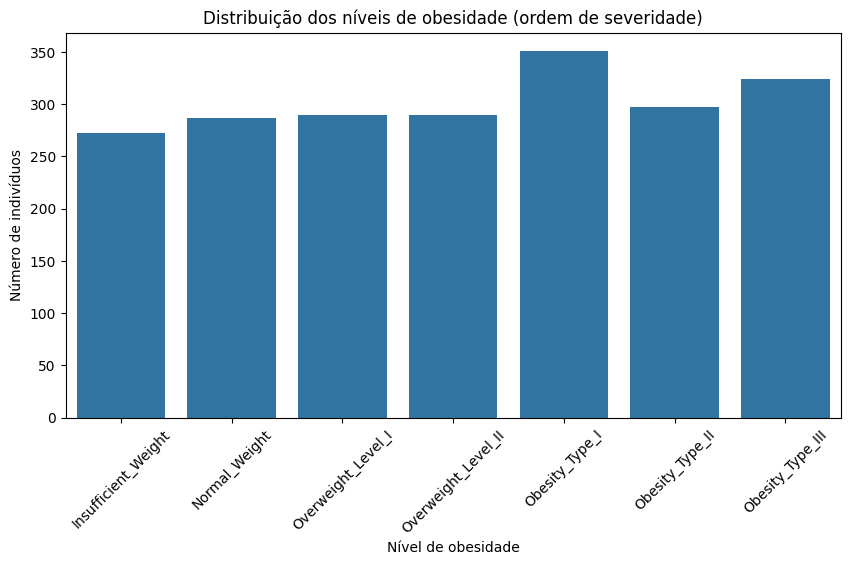

In [172]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x="Obesity",
    order=ordem_severidade
)
plt.xticks(rotation=45)
plt.title("Distribuição dos níveis de obesidade (ordem de severidade)")
plt.ylabel("Número de indivíduos")
plt.xlabel("Nível de obesidade")
plt.show()

### EDA fatores antropometricos

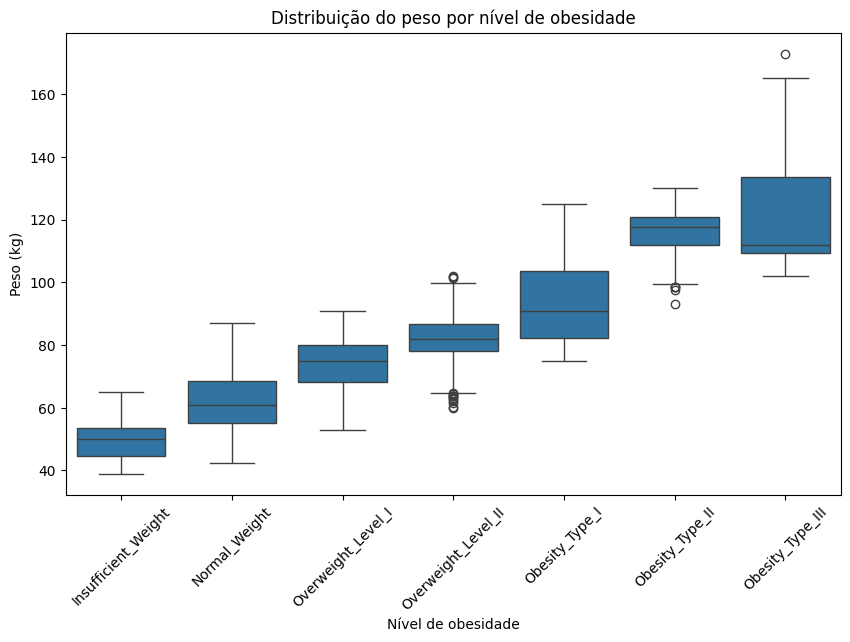

In [173]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="Obesity",
    y="Weight",
    order=ordem_severidade
)
plt.xticks(rotation=45)
plt.title("Distribuição do peso por nível de obesidade")
plt.ylabel("Peso (kg)")
plt.xlabel("Nível de obesidade")
plt.show()

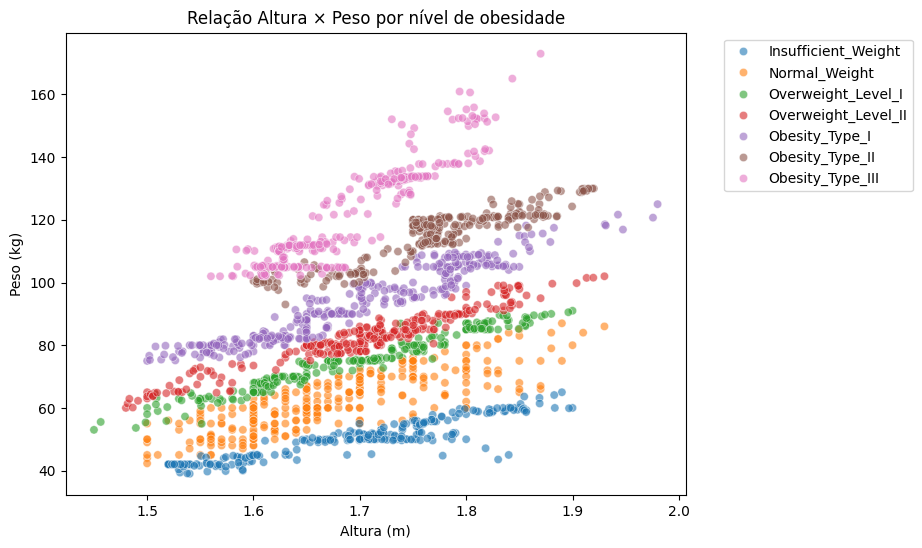

In [174]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue="Obesity",
    hue_order=ordem_severidade,
    alpha=0.6
)
plt.title("Relação Altura × Peso por nível de obesidade")
plt.xlabel("Altura (m)")
plt.ylabel("Peso (kg)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### EDA habitos vs obesidade

In [175]:
habitos_labels = {
    "FAF": "Atividade física (frequência)",
    "CH2O": "Consumo diário de água",
    "FCVC": "Consumo de vegetais",
    "TUE": "Tempo de uso de telas"
}

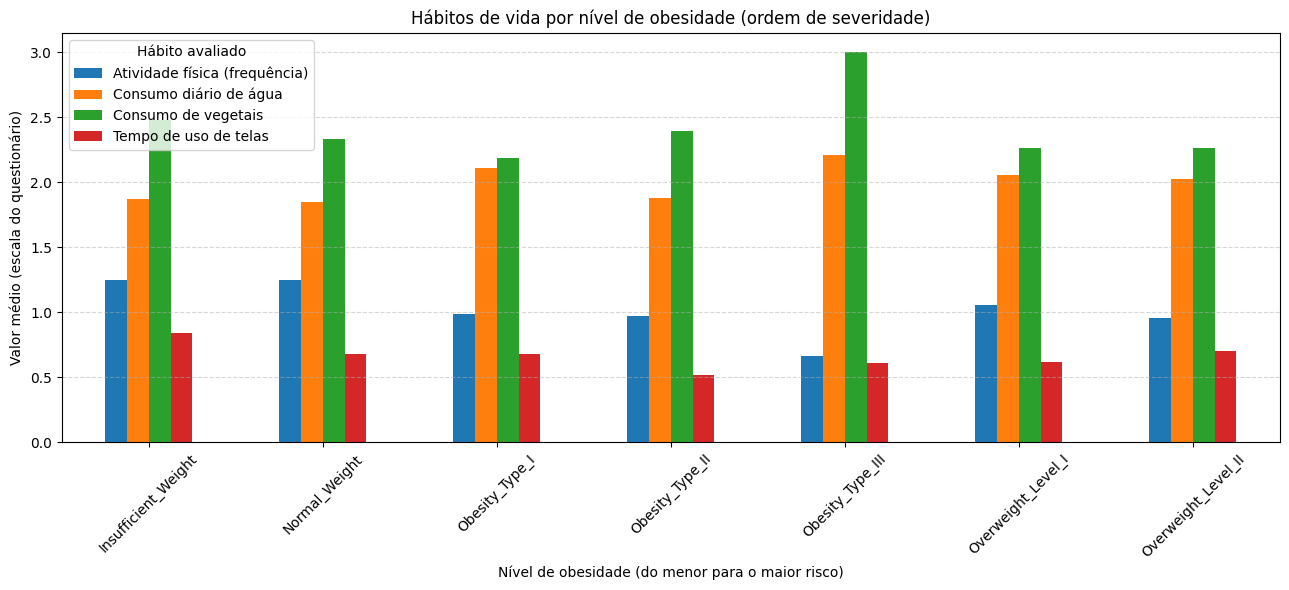

In [176]:
habitos_colunas = ["FAF", "CH2O", "FCVC", "TUE"]

habitos_por_obesidade = (
    df.groupby("Obesity")[habitos_colunas]
      .mean()
)

habitos_por_obesidade.rename(columns=habitos_labels).plot(
    kind="bar",
    figsize=(13,6)
)

plt.title("Hábitos de vida por nível de obesidade (ordem de severidade)")
plt.ylabel("Valor médio (escala do questionário)")
plt.xlabel("Nível de obesidade (do menor para o maior risco)")
plt.xticks(rotation=45)
plt.legend(title="Hábito avaliado")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### EDA variaveis categoricas vs obesidade

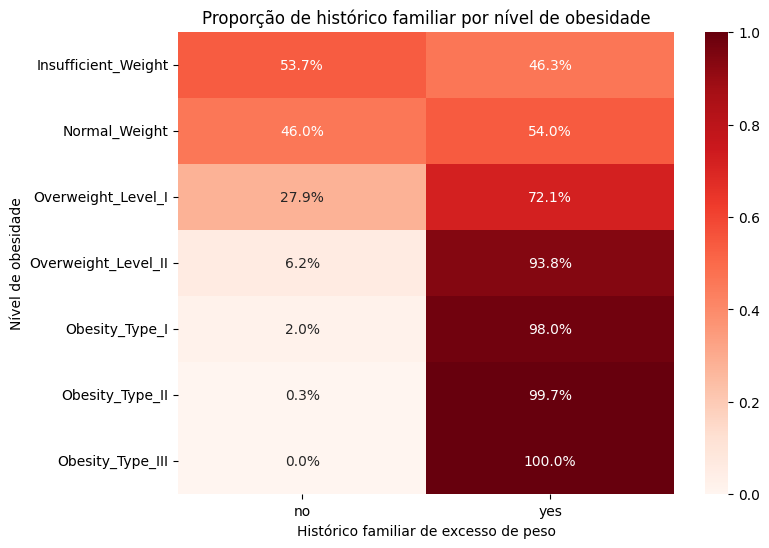

In [ ]:
fam_prop = (
    pd.crosstab(df["Obesity"], df["family_history"], normalize="index")
    .reindex(ordem_severidade)
)

plt.figure(figsize=(8,6))
sns.heatmap(
    fam_prop,
    annot=True,
    fmt=".1%",
    cmap="Reds"
)

plt.title("Proporção de histórico familiar por nível de obesidade")
plt.xlabel("Histórico familiar de excesso de peso")
plt.ylabel("Nível de obesidade")
plt.show()

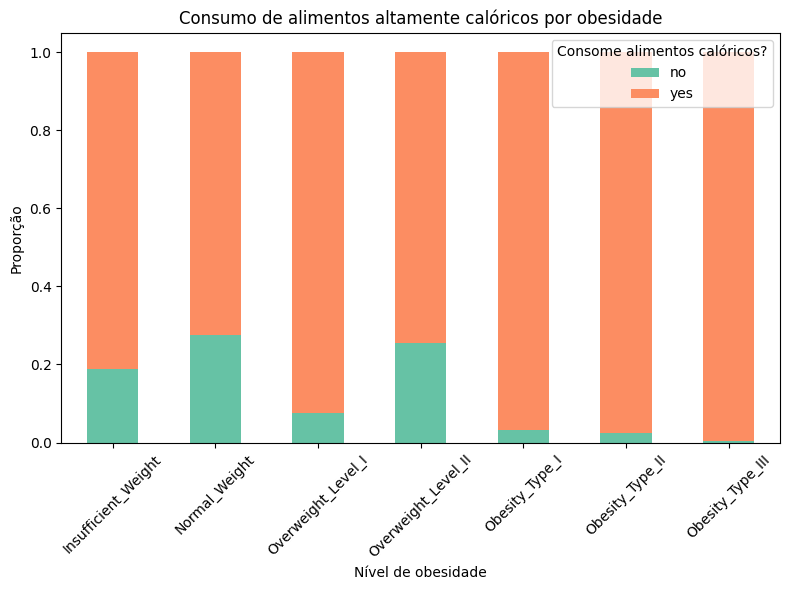

In [178]:
favc_prop = (
    pd.crosstab(df["Obesity"], df["FAVC"], normalize="index")
    .reindex(ordem_severidade)
)

favc_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["#66c2a5", "#fc8d62"]
)

plt.title("Consumo de alimentos altamente calóricos por obesidade")
plt.ylabel("Proporção")
plt.xlabel("Nível de obesidade")
plt.legend(title="Consome alimentos calóricos?")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

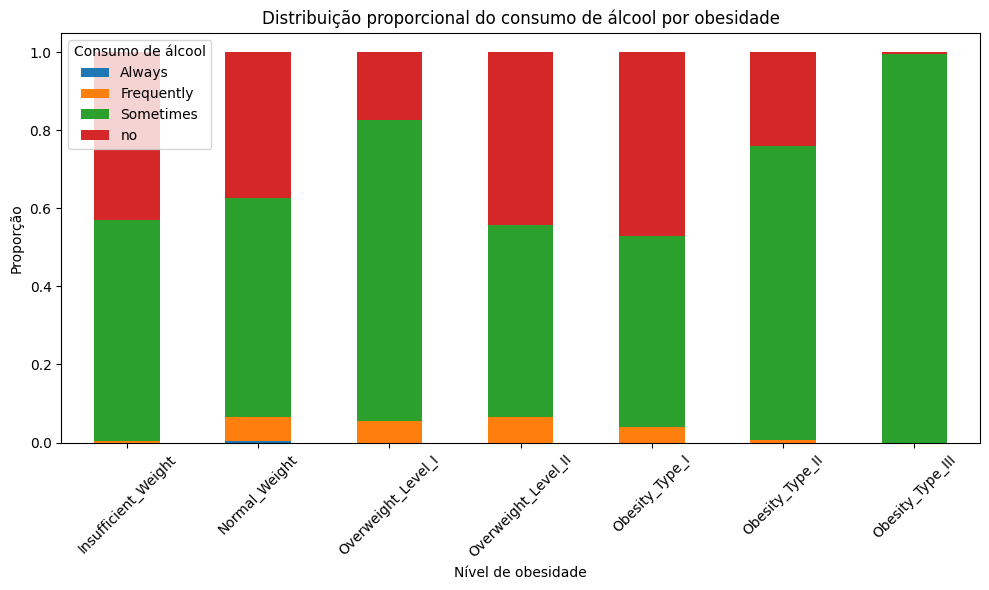

In [179]:
alc_prop = (
    pd.crosstab(df["Obesity"], df["CALC"], normalize="index")
    .reindex(ordem_severidade)
)

alc_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Distribuição proporcional do consumo de álcool por obesidade")
plt.ylabel("Proporção")
plt.xlabel("Nível de obesidade")
plt.legend(title="Consumo de álcool")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

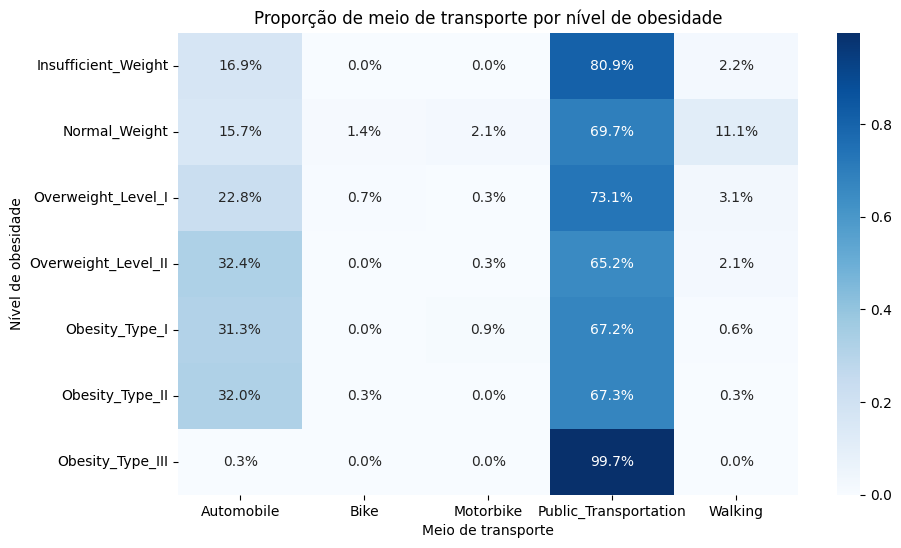

In [180]:
mtrans_prop = (
    pd.crosstab(df["Obesity"], df["MTRANS"], normalize="index")
    .reindex(ordem_severidade)
)

plt.figure(figsize=(10,6))
sns.heatmap(
    mtrans_prop,
    annot=True,
    fmt=".1%",
    cmap="Blues"
)
plt.title("Proporção de meio de transporte por nível de obesidade")
plt.xlabel("Meio de transporte")
plt.ylabel("Nível de obesidade")
plt.show()

### EDA variaveis numericas vs obesidade

In [181]:
variaveis_labels = {
    "Age": "Idade (anos)",
    "Height": "Altura (m)",
    "Weight": "Peso (kg)",
    "FCVC": "Consumo de vegetais",
    "NCP": "Número de refeições principais",
    "CH2O": "Consumo diário de água",
    "FAF": "Frequência de atividade física",
    "TUE": "Tempo de uso de telas"
}

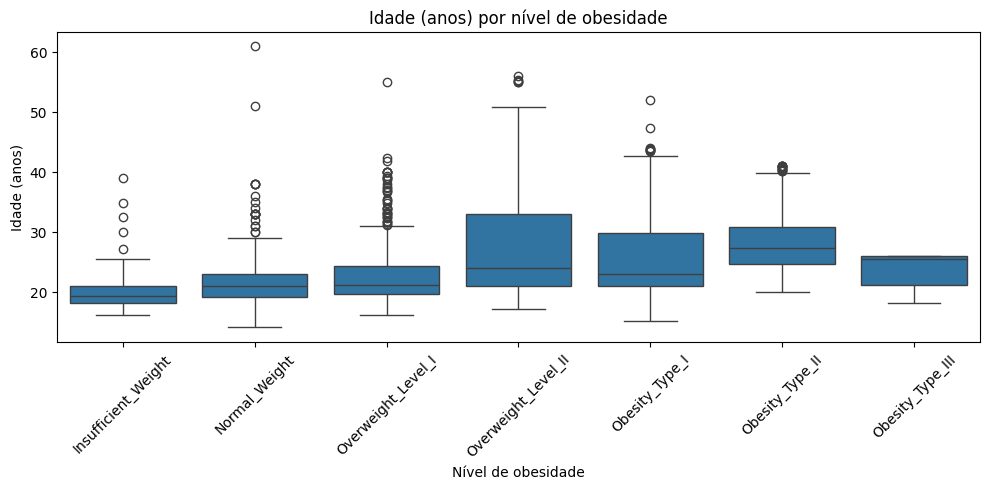

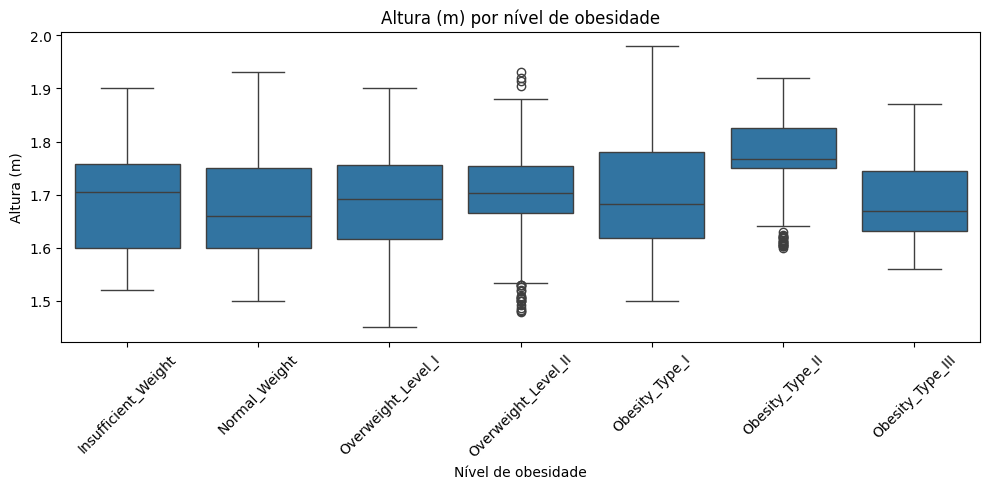

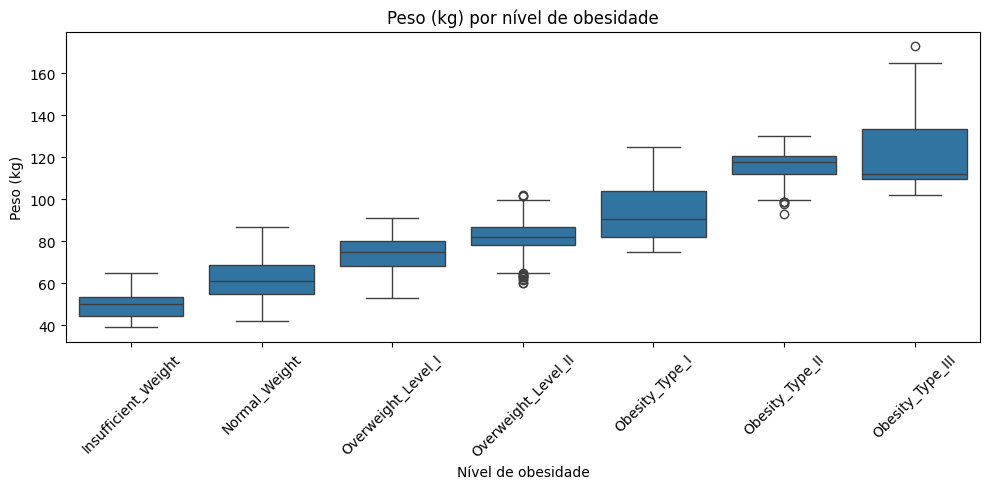

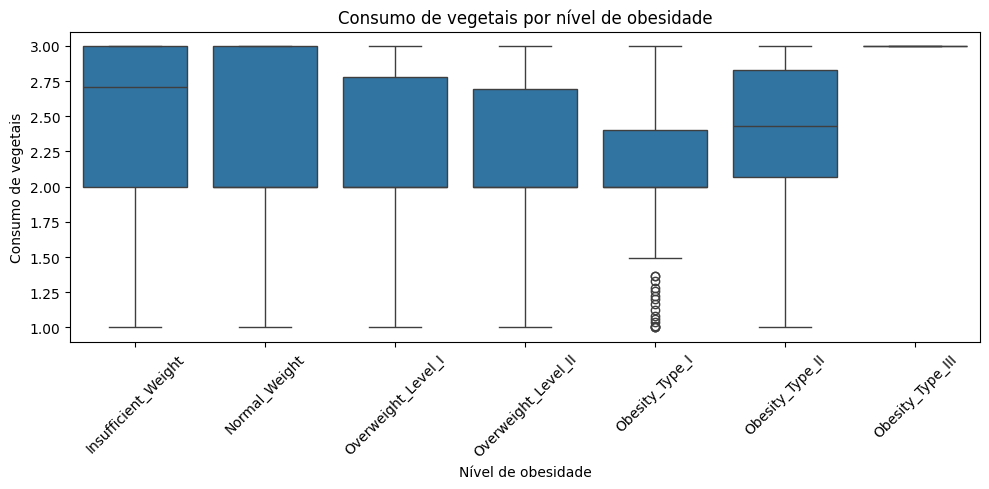

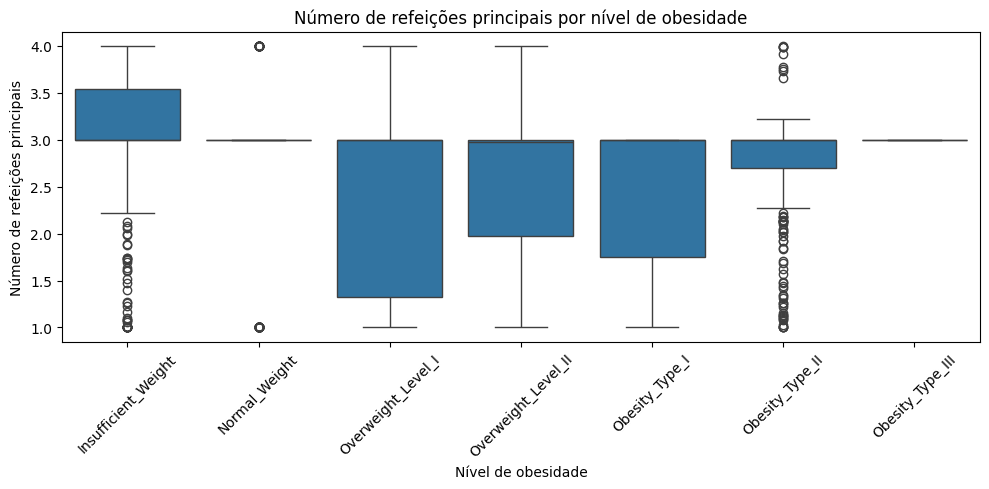

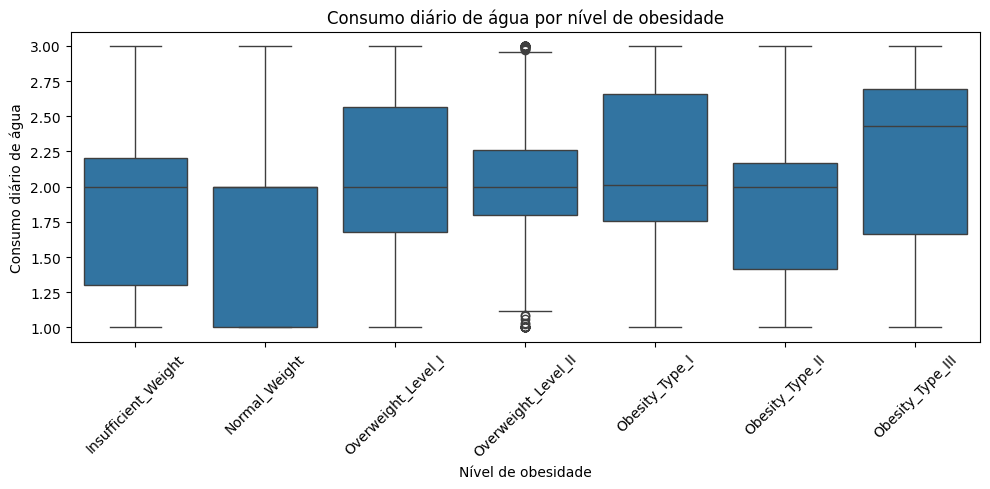

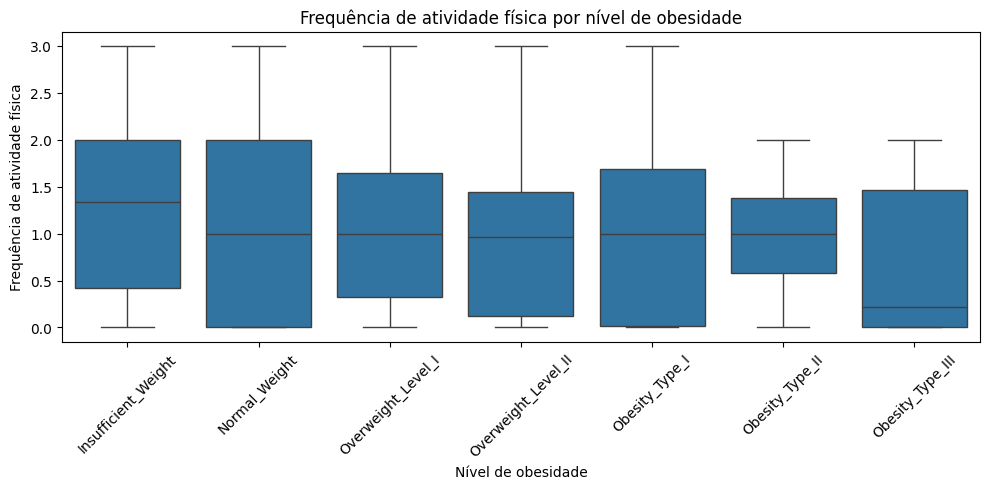

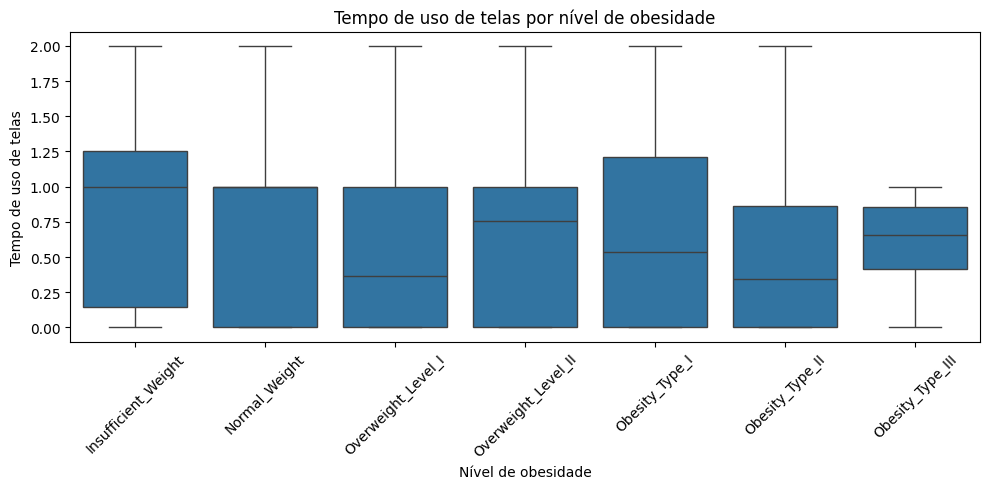

In [182]:
variaveis_numericas = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

for var in variaveis_numericas:
    plt.figure(figsize=(10,5))
    sns.boxplot(
        data=df,
        x="Obesity",
        y=var,
        order=ordem_severidade
    )
    plt.xticks(rotation=45)
    plt.title(f"{variaveis_labels[var]} por nível de obesidade")
    plt.ylabel(variaveis_labels[var])
    plt.xlabel("Nível de obesidade")
    plt.tight_layout()
    plt.show()

In [183]:
mapa_obesidade = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6
}

df["Obesity_ord"] = df["Obesity"].map(mapa_obesidade)

In [184]:
corr_obesidade = (
    df[variaveis_numericas + ["Obesity_ord"]]
    .corr()["Obesity_ord"]
    .sort_values(ascending=False)
)

corr_obesidade

Obesity_ord    1.000000
Weight         0.913251
Age            0.282913
FCVC           0.227759
Height         0.133565
CH2O           0.133008
NCP            0.026690
TUE           -0.107991
FAF           -0.199901
Name: Obesity_ord, dtype: float64

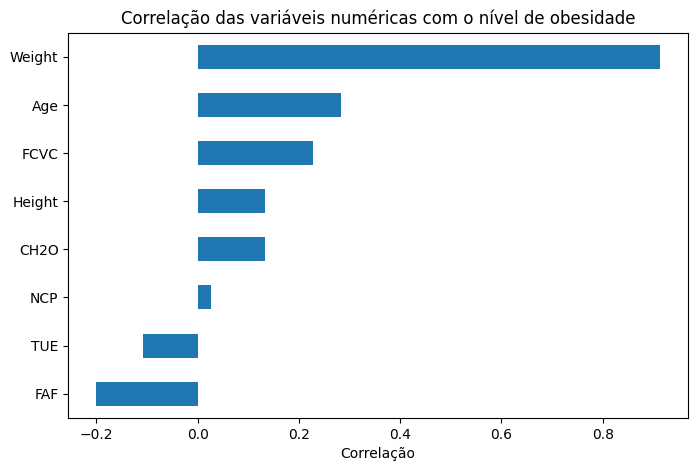

In [185]:
plt.figure(figsize=(8,5))
corr_obesidade.drop("Obesity_ord").plot(kind="barh")
plt.title("Correlação das variáveis numéricas com o nível de obesidade")
plt.xlabel("Correlação")
plt.gca().invert_yaxis()
plt.show()

### EDA conclusao

In [186]:
# ======================================================
# Conclusão da Análise Exploratória de Dados (EDA)
# ======================================================

# --- EDA fatores antropométricos -----------------------------------------
#
# A análise dos fatores antropométricos evidencia que o peso corporal é o
# principal elemento discriminante entre os níveis de obesidade.
# Observa-se um aumento progressivo do peso conforme a severidade da
# obesidade aumenta, validando clinicamente a classificação utilizada.
#
# A altura não apresenta relação direta com o nível de obesidade, indicando
# que o risco está mais associado ao excesso de peso do que à estatura
# isoladamente.
#

# --- EDA hábitos vs obesidade ---------------------------------------------
#
# Os gráficos de hábitos de vida por nível de obesidade, organizados em
# ordem de severidade, evidenciam um padrão progressivo de piora
# comportamental conforme aumenta a gravidade da obesidade.
#
# Indivíduos em níveis mais elevados apresentam menor frequência de
# atividade física, menor consumo de água e de vegetais, além de maior
# tempo de exposição a telas, caracterizando um perfil mais sedentário.
# Esses fatores representam alvos diretos para intervenções preventivas
# e de acompanhamento clínico.
#

# --- EDA variáveis categóricas vs obesidade -------------------------------
#
# A análise das variáveis categóricas em termos proporcionais indica
# associação relevante entre obesidade e fatores contextuais.
#
# Observa-se maior prevalência de histórico familiar positivo para excesso
# de peso, maior frequência de consumo de alimentos altamente calóricos,
# padrões de consumo de álcool mais frequentes e predominância de meios de
# transporte passivos em indivíduos com maior nível de obesidade.
#
# Esses achados reforçam o caráter multifatorial da obesidade, envolvendo
# aspectos genéticos, comportamentais e ambientais.
#

# --- EDA variáveis numéricas vs obesidade ---------------------------------
#
# A avaliação das variáveis numéricas por meio de boxplots demonstra que
# fatores relacionados ao estilo de vida apresentam associação clara com a
# progressão da obesidade.
#
# Destacam-se a redução da atividade física, menor ingestão de água e
# vegetais e aumento do comportamento sedentário conforme o nível de
# obesidade se agrava.
#

# --- EDA avaliação das principais variáveis -------------------------------
#
# A análise integrada das variáveis numéricas e categóricas indica que os
# fatores mais associados à obesidade estão relacionados principalmente a
# hábitos de vida modificáveis e ao histórico familiar.
#
# Esses resultados fornecem subsídios importantes para a equipe médica
# direcionar estratégias de prevenção, acompanhamento e intervenção,
# priorizando ações voltadas à mudança comportamental e à promoção de
# hábitos saudáveis.
#

# --- Insight clínico consolidado ------------------------------------------
#
# De forma geral, a análise exploratória evidencia que a obesidade está
# fortemente associada a comportamentos sedentários, padrões alimentares
# inadequados e fatores genéticos.
#
# A identificação desses padrões ao longo da escala de severidade permite
# orientar estratégias clínicas mais assertivas, com foco em intervenções
# precoces nos estágios iniciais de sobrepeso, reduzindo o risco de
# progressão para quadros mais severos.
#


## MACHINE LEARNING

### Pre-processamento

In [187]:
# Engenharia de atributos (conforme dicionário do dataset)
cols_comportamentais = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[cols_comportamentais] = df[cols_comportamentais].round()

# Separação features e target
X = df.drop(["Obesity", "Obesity_ord"], axis=1)
y = df["Obesity"]

# Encoding da variável alvo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Separação automática de variáveis numéricas e categóricas
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

# Pipeline de pré-processamento
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("scaler", StandardScaler())
    ]), num_features),

    ("cat", Pipeline([
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features)
])

### Split treino/validacao/teste

In [188]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # 0.25 * 0.8 = 0.2
    stratify=y_temp,
    random_state=42
)

### Pipeline de modelos

In [189]:
preprocessor_linear = ColumnTransformer([
    ("num", StandardScaler(), num_features),

    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ), cat_features)
])

preprocessor_tree = ColumnTransformer([
    ("num", "passthrough", num_features),

    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ), cat_features)
])

In [190]:
pipe_lr = Pipeline([
    ("prep", preprocessor_linear),
    ("model", LogisticRegression(C=0.5, max_iter=1000))
])

pipe_rf = Pipeline([
    ("prep", preprocessor_tree),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        min_samples_split=20,
        random_state=42
    ))
])

pipe_xgb = Pipeline([
    ("prep", preprocessor_tree),
    ("model", xgb.XGBClassifier(
        objective="multi:softmax",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.5,
        reg_lambda=1.5,
        random_state=42
    ))
])

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

### Metricas dos modelos

In [191]:
val_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    
    val_results.append({
        "Modelo": name,
        "Accuracy Validação": accuracy_score(y_val, y_val_pred),
        "F1-macro Validação": f1_score(y_val, y_val_pred, average="macro")
    })

val_df = pd.DataFrame(val_results)
val_df

,Modelo,Accuracy Validação,F1-macro Validação
0,Logistic Regression,0.834123,0.824964
1,Random Forest,0.890995,0.886597
2,XGBoost,0.940758,0.939969


### Cross-validation

In [192]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )
    cv_results.append({
        "Modelo": name,
        "CV F1-macro (mean)": scores["test_score"].mean()
    })

pd.DataFrame(cv_results)

c:\Users\UM2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\UM2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\UM2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Modelo,CV F1-macro (mean)
0,Logistic Regression,0.819453
1,Random Forest,0.859414
2,XGBoost,0.935815


### Metricas finais

In [193]:
resultados_finais = []

for nome, model in models.items():

    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)

    f1_val = f1_score(y_val, pred_val, average="macro")

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro"
    )

    f1_cv = cv_scores.mean()

    pred_test = model.predict(X_test)

    f1_test = f1_score(y_test, pred_test, average="macro")
    acc_test = accuracy_score(y_test, pred_test)

    resultados_finais.append({
        "Modelo": nome,
        "F1 Validação": f1_val,
        "F1 CV (mean)": f1_cv,
        "F1 Teste": f1_test,
        "Accuracy Teste": acc_test
    })

df_resultados_final = pd.DataFrame(resultados_finais)

display(
    df_resultados_final.sort_values(
        "F1 Teste",
        ascending=False
    )
)

c:\Users\UM2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\UM2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\UM2\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Modelo,F1 Validação,F1 CV (mean),F1 Teste,Accuracy Teste
2,XGBoost,0.939969,0.942362,0.911731,0.912530
1,Random Forest,0.886597,0.867989,0.882041,0.884161
0,Logistic Regression,0.824964,0.816197,0.831401,0.836879


### Escolha do modelo final

In [194]:
# Apesar do XGBoost apresentar maior F1-macro, o Random Forest foi escolhido como modelo final por apresentar maior estabilidade entre validação, cross-validation e teste, reduzindo risco de degradação em ambiente de produção

In [195]:
final_model = pipe_rf
final_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [196]:
y_test_pred = final_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=le.classes_
    )
)

                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.94      0.94        54
      Normal_Weight       0.75      0.79      0.77        58
     Obesity_Type_I       0.91      0.89      0.90        70
    Obesity_Type_II       0.91      0.98      0.94        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.79      0.79        58
Overweight_Level_II       0.87      0.79      0.83        58

           accuracy                           0.88       423
          macro avg       0.88      0.88      0.88       423
       weighted avg       0.89      0.88      0.88       423



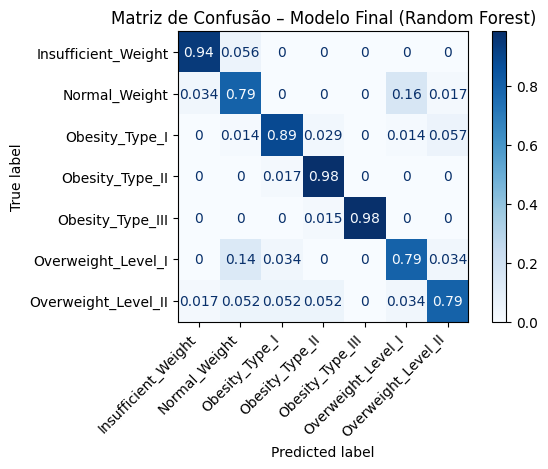

In [197]:
disp = ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    normalize="true",
    display_labels=le.classes_,
    cmap=plt.cm.Blues
)

plt.title("Matriz de Confusão – Modelo Final (Random Forest)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

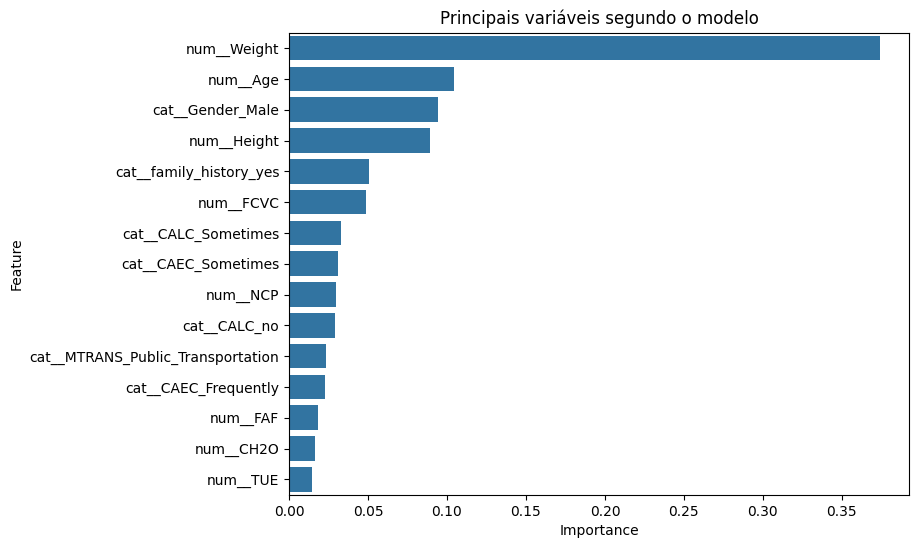

In [198]:
feature_names = final_model.named_steps["prep"].get_feature_names_out()

importances = final_model.named_steps["model"].feature_importances_

feat_imp = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp,
    x="Importance",
    y="Feature"
)
plt.title("Principais variáveis segundo o modelo")
plt.show()

### Salvando o modelo

In [200]:
joblib.dump(final_model, "model.joblib")
joblib.dump(le, "label_encoder.joblib")

['label_encoder.joblib']